# NB04: Patient Ecology & Engraftability

**Project**: CF Protective Microbiome Formulation Design  
**Goal**: Test H3 — which species are ubiquitous, metabolically active, and safe for formulation?

Engraftability = prevalence × activity. Species that are common across patients AND transcriptionally active (high metaRS/metaG ratio) are most likely to persist in a probiotic formulation.

**Input**: `~/protect/gold/` (metaG/metaRS CPM, abundance, patient metadata, bridge table)  
**Output**: `data/species_engraftability.tsv`

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

GOLD = Path.home() / 'protect' / 'gold'
DATA = Path('..') / 'data'
FIGS = Path('..') / 'figures'

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

metag = pd.read_parquet(GOLD / 'fact_metag_cpm.snappy.parquet')
metars = pd.read_parquet(GOLD / 'fact_metars_cpm.snappy.parquet')
patients = pd.read_parquet(GOLD / 'dim_patient_sample.snappy.parquet')
bridge = pd.read_parquet(GOLD / 'bridge_isolate_metagenomics.snappy.parquet')
isolates = pd.read_parquet(GOLD / 'dim_isolate.snappy.parquet')
pa_comp = pd.read_parquet(GOLD / 'fact_pa_competitors.snappy.parquet')

print(f'MetaG CPM: {len(metag)} rows, {metag.species.nunique()} species, {metag["sample"].nunique()} samples')
print(f'MetaRS CPM: {len(metars)} rows, {metars.species.nunique()} species, {metars["sample"].nunique()} samples')

MetaG CPM: 9916 rows, 134 species, 74 samples
MetaRS CPM: 9916 rows, 134 species, 74 samples


## 1. Species Prevalence & Abundance Across Patients

In [2]:
# Per-species metrics from metaG
metag['cpm'] = pd.to_numeric(metag['cpm'], errors='coerce')
metars['cpm'] = pd.to_numeric(metars['cpm'], errors='coerce')

n_samples_g = metag['sample'].nunique()
n_samples_r = metars['sample'].nunique()

# Prevalence: fraction of samples where species is detected (CPM > 0)
prev_g = metag[metag.cpm > 0].groupby('species')['sample'].nunique() / n_samples_g
prev_r = metars[metars.cpm > 0].groupby('species')['sample'].nunique() / n_samples_r

# Mean abundance
abund_g = metag.groupby('species')['cpm'].mean()
abund_r = metars.groupby('species')['cpm'].mean()

# Combine
ecology = pd.DataFrame({
    'prevalence_metag': prev_g,
    'prevalence_metars': prev_r,
    'mean_cpm_metag': abund_g,
    'mean_cpm_metars': abund_r
}).fillna(0)

# Activity ratio: metaRS / metaG (transcriptional activity per unit DNA)
ecology['activity_ratio'] = (ecology.mean_cpm_metars + 1) / (ecology.mean_cpm_metag + 1)

# Engraftability score: prevalence × log(activity_ratio + 1)
ecology['engraftability'] = ecology.prevalence_metag * np.log1p(ecology.activity_ratio)

print(f'Species in metagenomics: {len(ecology)}')
print(f'\nTop 20 by engraftability:')
print(ecology.nlargest(20, 'engraftability').round(3).to_string())

Species in metagenomics: 134

Top 20 by engraftability:
                                      prevalence_metag  prevalence_metars  mean_cpm_metag  mean_cpm_metars  activity_ratio  engraftability
species                                                                                                                                   
Moraxella nonliquefaciens                        0.743              0.743          33.505         5335.421         154.658           3.752
Propionibacterium acidifaciens                   0.851              0.851          71.755         4435.920          60.985           3.513
Catonella morbi                                  0.784              0.784         202.738        17677.401          86.770           3.507
Fusobacterium vincentii                          0.743              0.743        1362.724       137080.570         100.520           3.434
Alloprevotella sp900095835                       0.770              0.770         200.120         8880.138    

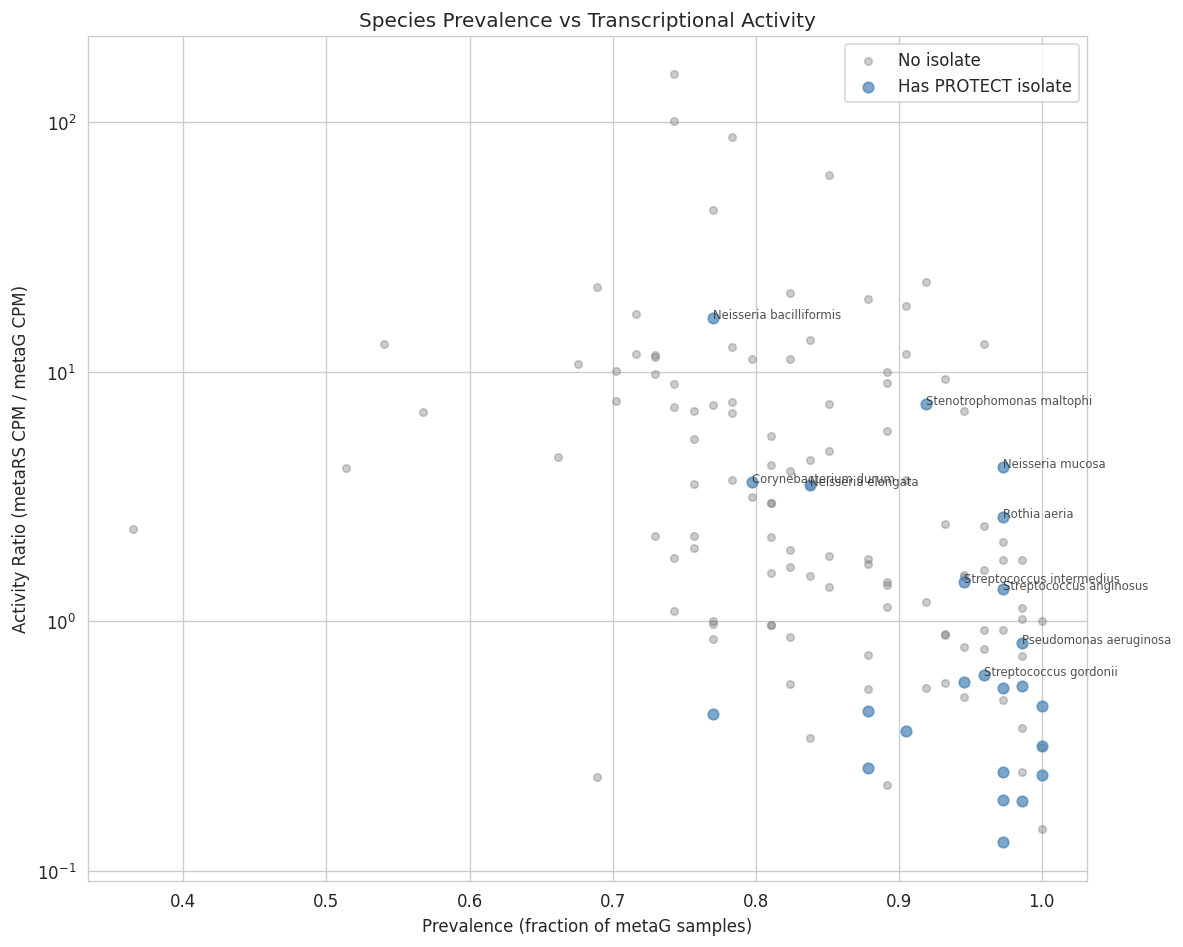

In [3]:
# Prevalence vs activity scatter
fig, ax = plt.subplots(figsize=(10, 8))
# Color by whether species has isolates in PROTECT
bridge_species = set(bridge.isolate_taxon.unique())
has_isolate = ecology.index.isin(bridge_species)

ax.scatter(ecology.loc[~has_isolate, 'prevalence_metag'], 
           ecology.loc[~has_isolate, 'activity_ratio'],
           alpha=0.4, s=20, c='grey', label='No isolate')
ax.scatter(ecology.loc[has_isolate, 'prevalence_metag'], 
           ecology.loc[has_isolate, 'activity_ratio'],
           alpha=0.7, s=40, c='steelblue', label='Has PROTECT isolate')

# Label top engraftable species with isolates
top_engraft = ecology[has_isolate].nlargest(10, 'engraftability')
for sp in top_engraft.index:
    ax.annotate(sp[:25], (ecology.loc[sp, 'prevalence_metag'], ecology.loc[sp, 'activity_ratio']),
                fontsize=7, alpha=0.8)

ax.set_xlabel('Prevalence (fraction of metaG samples)')
ax.set_ylabel('Activity Ratio (metaRS CPM / metaG CPM)')
ax.set_title('Species Prevalence vs Transcriptional Activity')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / '04_prevalence_vs_activity.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. FDA Safety Filter

In [4]:
# Flag unsafe species
unsafe_keywords = ['Pseudomonas aeruginosa', 'Klebsiella', 'Acinetobacter baumannii',
                   'Serratia', 'Citrobacter', 'Enterobacter', 'Enterococcus faecalis',
                   'Stenotrophomonas', 'Burkholderia', 'Staphylococcus aureus',
                   'Escherichia coli', 'Bacillus cereus', 'Bacillus_A cereus',
                   'Achromobacter', 'Ralstonia']

ecology['is_safe'] = ~ecology.index.str.contains('|'.join(unsafe_keywords), case=False, na=False)

safe_engraftable = ecology[ecology.is_safe & (ecology.prevalence_metag > 0.3)]
print(f'Safe species with >30% prevalence: {len(safe_engraftable)}')
print(safe_engraftable.nlargest(20, 'engraftability').round(3).to_string())

Safe species with >30% prevalence: 129
                                      prevalence_metag  prevalence_metars  mean_cpm_metag  mean_cpm_metars  activity_ratio  engraftability  is_safe
species                                                                                                                                            
Moraxella nonliquefaciens                        0.743              0.743          33.505         5335.421         154.658           3.752     True
Propionibacterium acidifaciens                   0.851              0.851          71.755         4435.920          60.985           3.513     True
Catonella morbi                                  0.784              0.784         202.738        17677.401          86.770           3.507     True
Fusobacterium vincentii                          0.743              0.743        1362.724       137080.570         100.520           3.434     True
Alloprevotella sp900095835                       0.770              0.770

## 3. PA Competitors from Metagenomics

In [5]:
# Metagenomics-derived PA competition scores
pa_comp['competition_score'] = pd.to_numeric(pa_comp['competition_score'], errors='coerce')
pa_mean = pa_comp.groupby('competitor')['competition_score'].agg(['mean','std','count']).sort_values('mean', ascending=False)
pa_mean.columns = ['mean_competition', 'std_competition', 'n_samples']

print('Top metagenomics-derived PA competitors:')
print(pa_mean.head(20).round(3).to_string())

# Merge with engraftability
pa_mean_eco = pa_mean.merge(ecology, left_index=True, right_index=True, how='inner')
print(f'\nPA competitors with ecology data: {len(pa_mean_eco)}')

Top metagenomics-derived PA competitors:
                             mean_competition  std_competition  n_samples
competitor                                                               
Achromobacter xylosoxidans              3.124            1.094          2
Actinomyces dentalis                    2.993            1.077          3
Arachnia propionica                     2.774            0.864          3
Prevotella melaninogenica               2.367            0.833         14
Neisseria elongata                      2.288              NaN          1
Haemophilus influenzae_F                2.174            0.354          2
Streptococcus thermophilus              1.919            0.445          7
Rothia dentocariosa                     1.906            0.418         12
Prevotella scopos                       1.901            0.666          4
Staphylococcus aureus                   1.898            0.750          2
Prevotella histicola                    1.887            0.011         

In [6]:
# Bridge: link isolate species to metagenomics features
print('=== Isolate-Metagenomics Bridge ===')
print(bridge.to_string())
print(f'\nMatch levels: {bridge.match_level.value_counts().to_dict()}')
print(f'Match types: {bridge.match_type.value_counts().to_dict()}')

=== Isolate-Metagenomics Bridge ===
                        isolate_taxon           metagenomic_feature match_level       match_type  isolate_count
0           Streptococcus sp001553685                 Streptococcus       genus       genus_only             10
1        Stenotrophomonas maltophilia  Stenotrophomonas maltophilia     species            exact             16
2             Streptococcus oralis_BH                 Streptococcus       genus       genus_only              1
3           Streptococcus sp024295625                 Streptococcus       genus       genus_only              1
4                        Pauljensenia                  Pauljensenia       genus  genus_aggregate              2
5             Streptococcus sanguinis                 Streptococcus       genus       genus_only             92
6        Lacticaseibacillus paracasei            Lacticaseibacillus       genus       genus_only             32
7              Streptococcus mitis_CU                 Streptococcus 

In [7]:
# Save engraftability scores
ecology.to_csv(DATA / 'species_engraftability.tsv', sep='\t')
print(f'Saved: {DATA}/species_engraftability.tsv ({len(ecology)} species)')

print(f'\n=== NB04 SUMMARY ===')
print(f'Species in metagenomics: {len(ecology)}')
print(f'Species with isolates in PROTECT: {has_isolate.sum()}')
print(f'Safe species (>30% prevalence): {len(safe_engraftable)}')
print(f'PA competitors from metagenomics: {len(pa_mean)}')

Saved: ../data/species_engraftability.tsv (134 species)

=== NB04 SUMMARY ===
Species in metagenomics: 134
Species with isolates in PROTECT: 24
Safe species (>30% prevalence): 129
PA competitors from metagenomics: 40
